# Построение

In [359]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [360]:
def print_multiple_accuracy(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("train_loss", "test_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        train_acc = data["history"]["train_acc"]
        test_acc = data["history"]["test_acc"]


        print(label)
        print("train_acc (finish):", train_acc[-1])
        print("test_acc (finish): ", test_acc[-1])
        print('\n')

In [361]:
# def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison"):
#     """
#     run_dirs: пути к папкам
#     labels: подписи (["SignMuon", "Adam", "SGD"])
#     metric: что рисуем ("train_loss", "test_loss", )
#     """

#     plt.figure(figsize=(8, 6))

#     markers = ["o", "s", "^", "D", "v", "x", "*"] 

#     for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
#         run_dir = Path(run_dir)

#         with open(run_dir / "metrics.json", "r") as f:
#             data = json.load(f)

#         history = data["history"]
#         values = history[metric]
#         values = np.array(values)
        
#         epochs = np.arange(0, len(values))

#         plt.plot(
#             epochs, 
#             values, 
#             label=label,
#             # marker=markers[i % len(markers)],
#             # markersize=5, 
#             # markevery=len(values)//5,
#         )

#     metric_names = {
#         "train_loss": "Train Loss",
#         "test_loss": "Test Loss",
#         "train_acc": "Train Accuracy",
#         "test_acc": "Test Accuracy",
#     }
#     ylabel = metric_names.get(metric, metric)
#     plt.ylabel(ylabel, fontsize=14)
#     plt.xlabel("Epochs", fontsize=14)
#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)
#     #plt.title(title)
#     plt.grid(True)
#     plt.legend(fontsize=12)
#     plt.tight_layout()
#     plt.show()


In [362]:
# ============================================================
# Publication-ready plotting style (NeurIPS / ICML / AAAI)
# Run this cell once; all subsequent figures inherit the style.
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.9,
    "lines.linewidth": 3.5,
    "lines.markersize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.75",
    "legend.fancybox": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# tab10 first five + medium pink as the 6th (explicit hex codes).
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
          "#915cc2", "#4A3322", "#7f7f7f", "#bcbd22", "#17becf"]
_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

_METRIC_NAMES = {
    "train_loss": "Train Loss",
    "test_loss": "Test Loss",
    "train_acc": "Train Accuracy",
    "test_acc": "Test Accuracy",
}


def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison",
                            xlabel="Epochs", ylabel=None, figsize=(10, 6.5),
                            markevery=None, save_path=None):
    """Plot one history metric across several centralized runs."""
    fig, ax = plt.subplots(figsize=figsize)

    for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
        run_dir = Path(run_dir)
        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)
        values = np.array(data["history"][metric])
        epochs = np.arange(0, len(values))

        me = markevery if markevery is not None else max(1, len(values) // 6)
        color = COLORS[i % len(COLORS)]
        marker = _MARKERS[i % len(_MARKERS)]

        ax.plot(
            epochs, values,
            label=label,
            color=color,
            linewidth=3.5,
            alpha=0.85,
            # marker=marker,
            # markersize=11,
            # markerfacecolor=color,
            # markeredgecolor="white",
            # markeredgewidth=1.5,
            # markevery=me,
            solid_capstyle="round",
            zorder=3,
        )

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel if ylabel else _METRIC_NAMES.get(metric, metric), fontsize=20)
    ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
    ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)
    ax.legend(loc="best", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# MNIST -- CNN (without AdamW)


In [363]:
# print_multiple_accuracy(
#     run_dirs=[
#         "saves/mnist_signmuon",
#         "saves/mnist_muon",
#         "saves/mnist_signsgd",
#         "saves/mnist_sgd",
#         "saves/mnist_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     title="MNIST",
# )

In [364]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/mnist_signmuon",
#         "saves/mnist_muon",
#         "saves/mnist_signsgd",
#         "saves/mnist_sgd",
#         "saves/mnist_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="train_loss",
#     title="MNIST Loss",
# )

In [365]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/mnist_signmuon",
#         "saves/mnist_muon",
#         "saves/mnist_signsgd",
#         "saves/mnist_sgd",
#         "saves/mnist_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="train_acc",
#     title="MNIST Accuracy",
# )

In [366]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/mnist_signmuon",
#         "saves/mnist_muon",
#         "saves/mnist_signsgd",
#         "saves/mnist_sgd",
#         "saves/mnist_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="test_loss",
#     title="MNIST Loss",
# )

In [367]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/mnist_signmuon",
#         "saves/mnist_muon",
#         "saves/mnist_signsgd",
#         "saves/mnist_sgd",
#         "saves/mnist_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="test_acc",
#     title="MNIST Accuracy",
# )

#  CIFAR10 -- CNN (without AdamW)


In [368]:
# print_multiple_accuracy(
#     run_dirs=[
#         "saves/cifar10_signmuon",
#         "saves/cifar10_muon",
#         "saves/cifar10_signsgd",
#         "saves/cifar10_sgd",
#         "saves/cifar10_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     title="CIFAR10",
# )

In [369]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_signmuon",
#         "saves/cifar10_muon",
#         "saves/cifar10_signsgd",
#         "saves/cifar10_sgd",
#         "saves/cifar10_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="train_loss",
#     title="CIFAR10 Loss",
# )

In [370]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_signmuon",
#         "saves/cifar10_muon",
#         "saves/cifar10_signsgd",
#         "saves/cifar10_sgd",
#         "saves/cifar10_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="train_acc",
#     title="CIFAR10 Accuracy",
# )

In [371]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_signmuon",
#         "saves/cifar10_muon",
#         "saves/cifar10_signsgd",
#         "saves/cifar10_sgd",
#         "saves/cifar10_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="test_loss",
#     title="CIFAR10 Loss",
# )

In [372]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_signmuon",
#         "saves/cifar10_muon",
#         "saves/cifar10_signsgd",
#         "saves/cifar10_sgd",
#         "saves/cifar10_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD",
#         "SGD",
#         "Adam",
#     ],
#     metric="test_acc",
#     title="CIFAR10 Accuracy",
# )

# CIFAR -- Resnet18 (without AdamW)

In [373]:
# print_multiple_accuracy(
#     run_dirs=[
#         "saves/cifar10_resnet18_signmuon_wo_adam",
#         "saves/cifar10_resnet18_muon_wo_adam",
#         "saves/cifar10_resnet18_signsgd_wo_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD"
#     ],
#     title="CIFAR10",
# )



In [374]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_resnet18_signmuon_wo_adam",
#         "saves/cifar10_resnet18_muon_wo_adam",
#         "saves/cifar10_resnet18_signsgd_wo_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD"
#     ],
#     metric="train_loss",
#     title="CIFAR10 Loss",
#     save_path="train_loss_resnet"
# )

In [375]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_resnet18_signmuon_wo_adam",
#         "saves/cifar10_resnet18_muon_wo_adam",
#         "saves/cifar10_resnet18_signsgd_wo_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD"
#     ],
#     metric="test_loss",
#     title="CIFAR10 Loss",
#     save_path="test_loss_resnet"
# )

In [376]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_resnet18_signmuon_wo_adam",
#         "saves/cifar10_resnet18_muon_wo_adam",
#         "saves/cifar10_resnet18_signsgd_wo_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD"
#     ],
#     metric="train_acc",
#     title="CIFAR10 Accuracy",
#     save_path="train_acc_resnet"
# )

In [377]:
# plot_multiple_histories(
#     run_dirs=[
#         "saves/cifar10_resnet18_signmuon_wo_adam",
#         "saves/cifar10_resnet18_muon_wo_adam",
#         "saves/cifar10_resnet18_signsgd_wo_adam",
#     ],
#     labels=[
#         "SignMuon",
#         "Muon",
#         "SignSGD"
#     ],
#     metric="test_acc",
#     title="CIFAR10 Accuracy",
#     save_path="test_acc_resnet"
# )

# CIFAR -- Resnet18 (with AdamW)

In [378]:
print_multiple_accuracy(
    run_dirs=[
        "saves/cifar10_resnet18_signmuon",
        "saves/cifar10_resnet18_muon",
        "saves/cifar10_resnet18_signsgd",
        "saves/cifar10_resnet18_sgd",
        "saves/cifar10_resnet18_adam",
        "saves/cifar10_resnet18_ef_signmuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    title="CIFAR10",
)

CIFAR10
SignMuon
train_acc (finish): 0.99696
test_acc (finish):  0.9255


Muon
train_acc (finish): 0.99944
test_acc (finish):  0.937


SignSGD
train_acc (finish): 0.93198
test_acc (finish):  0.8911


SGD
train_acc (finish): 0.99986
test_acc (finish):  0.9393


Adam
train_acc (finish): 0.99776
test_acc (finish):  0.9303


EF-SignMuon
train_acc (finish): 0.99962
test_acc (finish):  0.9382




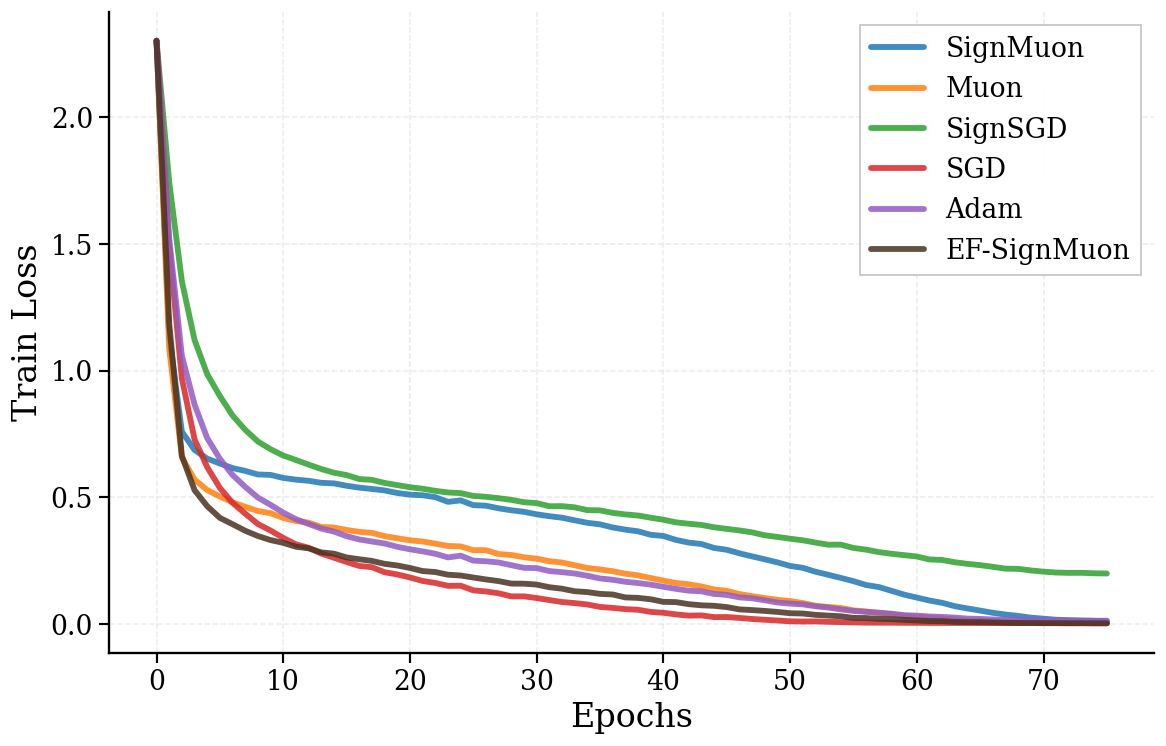

In [379]:
plot_multiple_histories(
    run_dirs=[
        "saves/cifar10_resnet18_signmuon",
        "saves/cifar10_resnet18_muon",
        "saves/cifar10_resnet18_signsgd",
        "saves/cifar10_resnet18_sgd",
        "saves/cifar10_resnet18_adam",
        "saves/cifar10_resnet18_ef_signmuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    metric="train_loss",
    title="CIFAR10 Loss",
    save_path="im_cen/train_loss_resnet"
)

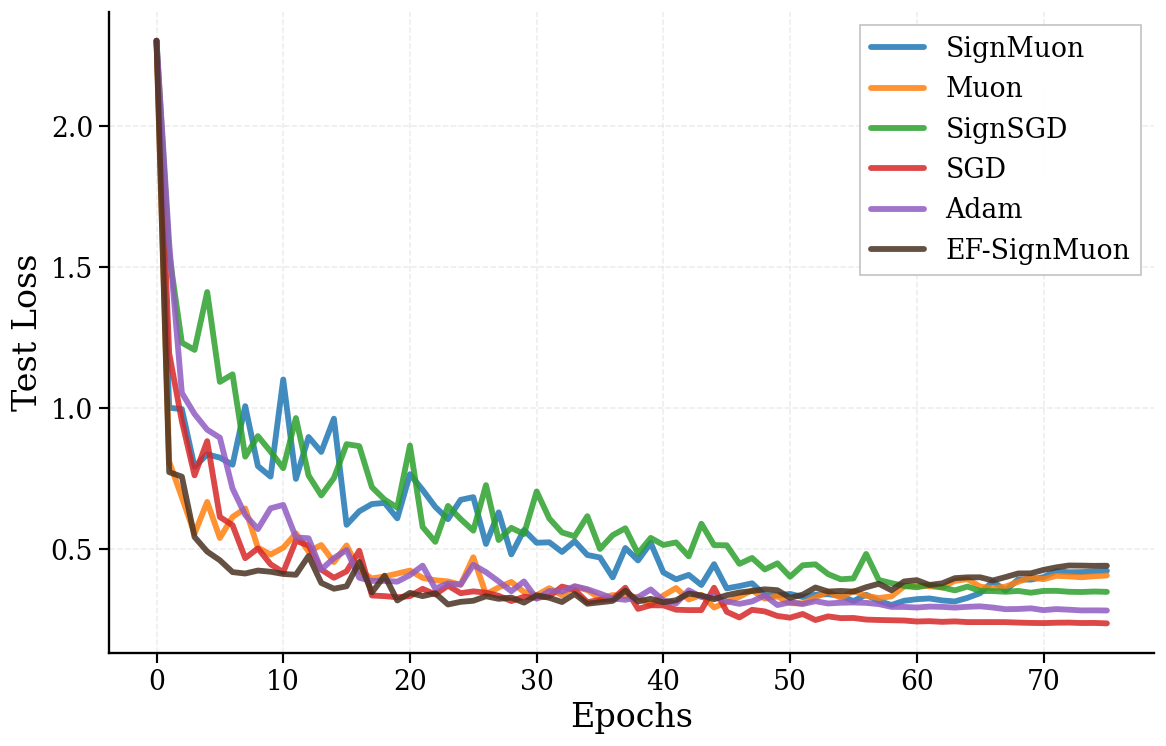

In [380]:
plot_multiple_histories(
    run_dirs=[
        "saves/cifar10_resnet18_signmuon",
        "saves/cifar10_resnet18_muon",
        "saves/cifar10_resnet18_signsgd",
        "saves/cifar10_resnet18_sgd",
        "saves/cifar10_resnet18_adam",
        "saves/cifar10_resnet18_ef_signmuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    metric="test_loss",
    title="CIFAR10 Loss",
    save_path="im_cen/test_loss_resnet"
)

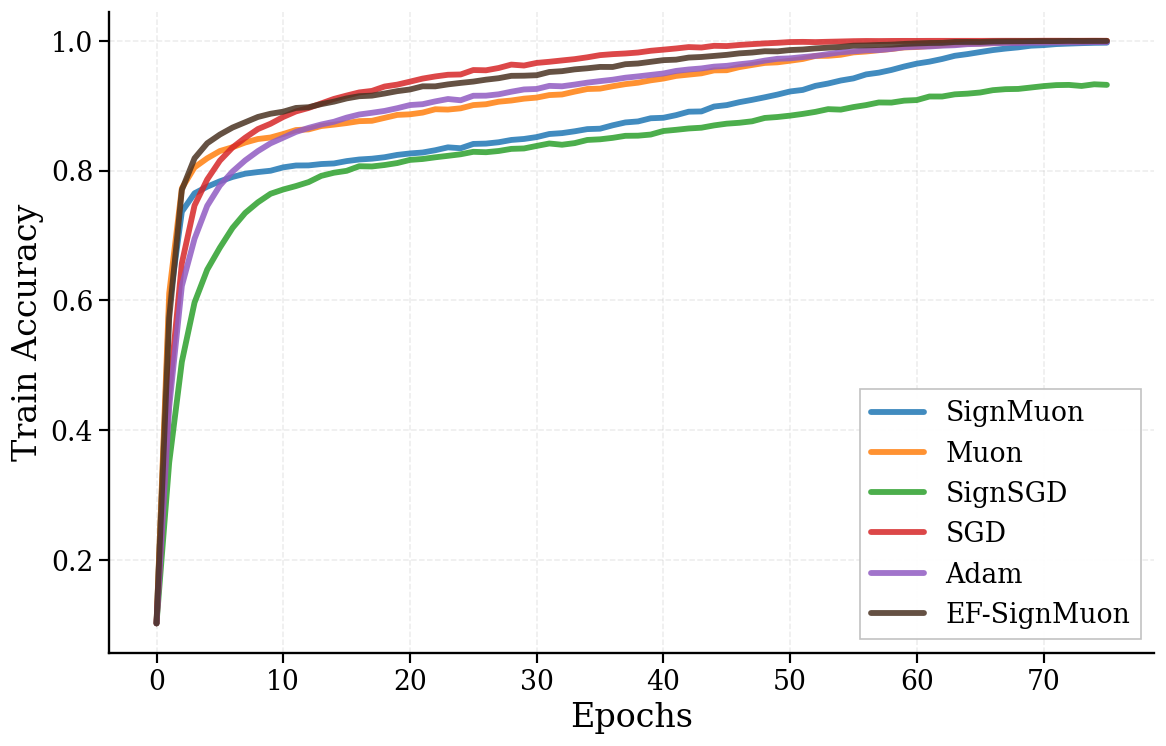

In [381]:
plot_multiple_histories(
    run_dirs=[
        "saves/cifar10_resnet18_signmuon",
        "saves/cifar10_resnet18_muon",
        "saves/cifar10_resnet18_signsgd",
        "saves/cifar10_resnet18_sgd",
        "saves/cifar10_resnet18_adam",
        "saves/cifar10_resnet18_ef_signmuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    metric="train_acc",
    title="CIFAR10 Accuracy",
    save_path="im_cen/train_acc_resnet"
)

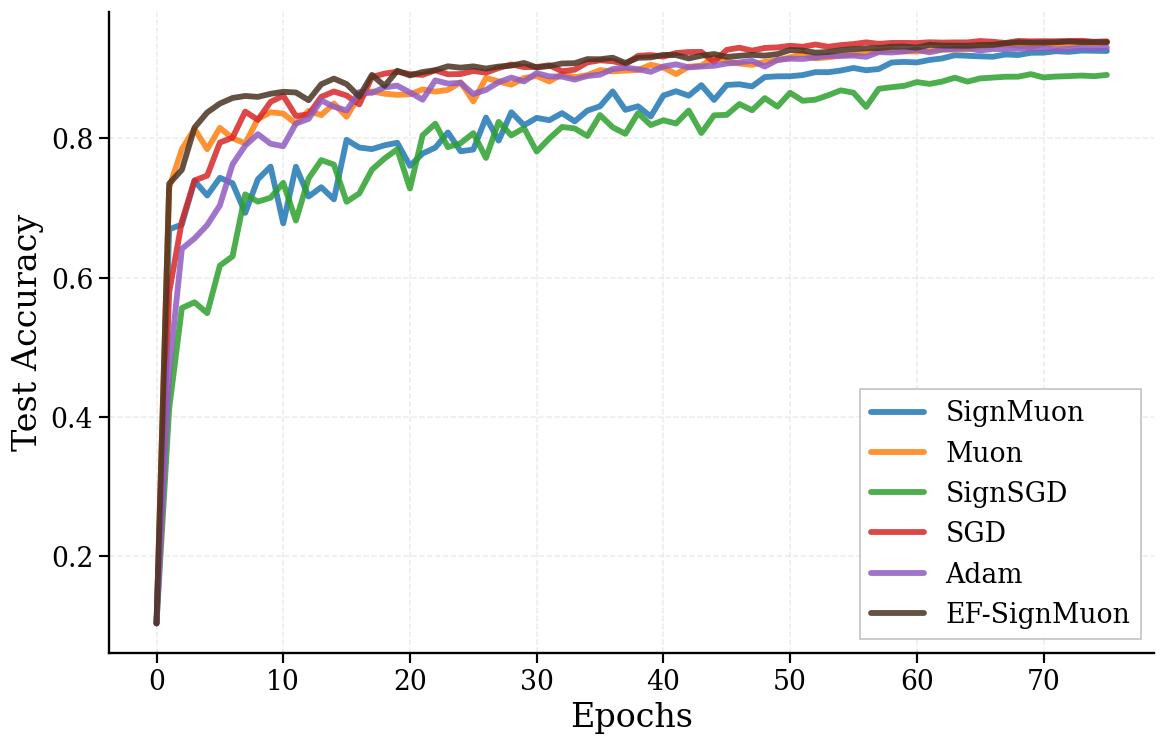

In [382]:
plot_multiple_histories(
    run_dirs=[
        "saves/cifar10_resnet18_signmuon",
        "saves/cifar10_resnet18_muon",
        "saves/cifar10_resnet18_signsgd",
        "saves/cifar10_resnet18_sgd",
        "saves/cifar10_resnet18_adam",
        "saves/cifar10_resnet18_ef_signmuon",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
        "EF-SignMuon",
    ],
    metric="test_acc",
    title="CIFAR10 Accuracy",
    save_path="im_cen/test_acc_resnet"
)